# A. Custom CNN Regression Model

Train: /kaggle/input/datasets/vananphan/objectdetection-andy/train/images
Valid: /kaggle/input/datasets/vananphan/objectdetection-andy/valid/images
Test : /kaggle/input/datasets/vananphan/objectdetection-andy/test/images


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         2,056 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,728 (84.86 MB)

 Trainable params: 22,246,728 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 23s 191ms/step - loss: 0.6143 - val_loss: 0.0329
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 180ms/step - loss: 0.0314 - val_loss: 0.0287
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 181ms/step - loss: 0.0288 - val_loss: 0.0308
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 15s 156ms/step - loss: 0.0298 - val_loss: 0.0269
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 134ms/step - loss: 0.0260 - val_loss: 0.0235
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.0261 - val_loss: 0.0245
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - loss: 0.0256 - val_loss: 0.0272
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - loss: 0.0255 - val_loss: 0.0255
Epoch 9/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - loss: 0.0242 - val_loss: 0.0226
Epoch 10/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 138ms/step - loss: 0.0236 - val_loss: 0.0229
Epoch 11/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 143ms/step - loss: 0.0225 - val_loss: 0.0212
Epoch 12/30
100/100

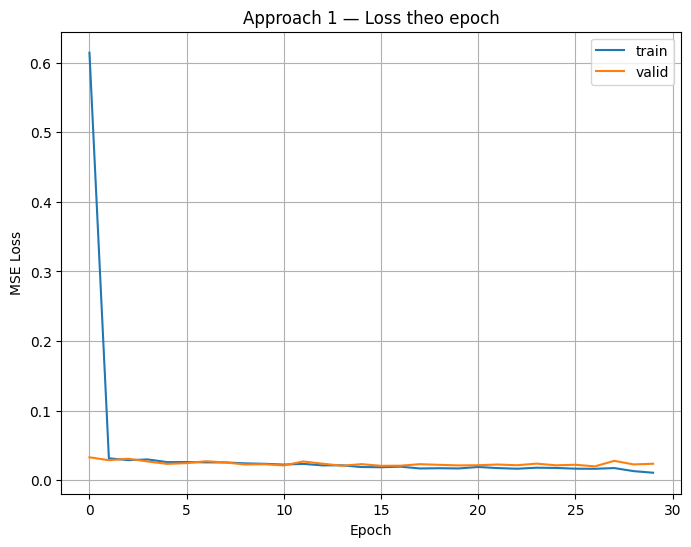

VALID IoU:
Mean IoU Head: 0.006459454
Mean IoU Body: 0.057665177
Mean IoU Overall: 0.032062314
TEST IoU:
Mean IoU Head: 0.006952417
Mean IoU Body: 0.06534095
Mean IoU Overall: 0.036146685


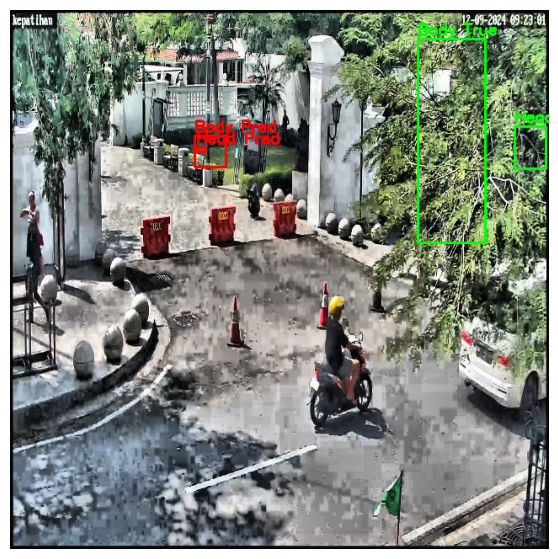

Saved CNN model to /kaggle/working/head_body_model_final.h5


In [2]:
# ============================================================
# APPROACH 1 — CNN Regression (FULL FINAL, ROBUST VERSION)
# ============================================================

import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# 1. DATASET PATHS (KAGGLE)
# ============================================================

dataset_path = "/kaggle/input/datasets/vananphan/objectdetection-andy"

train_dir = os.path.join(dataset_path, "train")
valid_dir = os.path.join(dataset_path, "valid")
test_dir  = os.path.join(dataset_path, "test")

train_img_dir = os.path.join(train_dir, "images")
train_lbl_dir = os.path.join(train_dir, "labels")

valid_img_dir = os.path.join(valid_dir, "images")
valid_lbl_dir = os.path.join(valid_dir, "labels")

test_img_dir = os.path.join(test_dir, "images")
test_lbl_dir = os.path.join(test_dir, "labels")

print("Train:", train_img_dir)
print("Valid:", valid_img_dir)
print("Test :", test_img_dir)

# ============================================================
# 2. PREPROCESSING: PAIR HEAD–BODY + GENERATOR
# ============================================================

def pick_head_body_pair(label_path):
    heads, bodies = [], []

    if not os.path.exists(label_path):
        return None

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls, xc, yc, w, h = map(float, parts)
            if int(cls) == 0:      # head class
                heads.append((xc, yc, w, h))
            elif int(cls) == 1:    # body class
                bodies.append((xc, yc, w, h))

    if len(heads) == 0 or len(bodies) == 0:
        return None

    best_pair, best_dist = None, float("inf")
    for h in heads:
        for b in bodies:
            dist = (h[0] - b[0])**2 + (h[1] - b[1])**2
            if dist < best_dist:
                best_dist = dist
                best_pair = (h, b)

    return best_pair


def yolo_generator(img_dir, lbl_dir, batch_size=8, img_size=224):
    images = sorted([f for f in os.listdir(img_dir)
                     if f.lower().endswith((".jpg", ".png", ".jpeg"))])

    while True:
        np.random.shuffle(images)
        X_batch, y_batch = [], []

        for img_name in images:
            img_path = os.path.join(img_dir, img_name)
            lbl_path = os.path.join(lbl_dir, img_name.rsplit(".",1)[0] + ".txt")

            if not os.path.exists(lbl_path):
                continue

            pair = pick_head_body_pair(lbl_path)
            if pair is None:
                continue

            head, body = pair

            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype(np.float32) / 255.0

            y = np.array([
                head[0], head[1], head[2], head[3],
                body[0], body[1], body[2], body[3]
            ], dtype=np.float32)

            X_batch.append(img)
            y_batch.append(y)

            if len(X_batch) == batch_size:
                yield np.array(X_batch), np.array(y_batch)
                X_batch, y_batch = [], []

# ============================================================
# 3. MODEL: DENSE(8) REGRESSION
# ============================================================

def build_model(img_size=224):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(img_size, img_size, 3)),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(8)  # 4 head + 4 body (YOLO format)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_model(img_size=224)
model.summary()

# ============================================================
# 4. TRAIN + GRAPH LOSS
# ============================================================

train_gen = yolo_generator(train_img_dir, train_lbl_dir, batch_size=8, img_size=224)
valid_gen = yolo_generator(valid_img_dir, valid_lbl_dir, batch_size=8, img_size=224)

history = model.fit(
    train_gen,
    steps_per_epoch=100,
    epochs=30,              # final version: more epochs
    validation_data=valid_gen,
    validation_steps=30
)

plt.figure(figsize=(8,6))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='valid')
plt.title("Approach 1 — Loss theo epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 5. IoU + CHUYỂN YOLO → XYXY
# ============================================================

def IoU(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    areaB = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)


def yolo_to_xyxy(bbox, W, H):
    xc, yc, w, h = bbox
    x1 = (xc - w/2) * W
    y1 = (yc - h/2) * H
    x2 = (xc + w/2) * W
    y2 = (yc + h/2) * H
    return [x1, y1, x2, y2]

# ============================================================
# 6. EVALUATE IoU IN VALID / TEST
# ============================================================

def evaluate_iou(model, img_dir, lbl_dir, max_samples=100, img_size=224):
    images = sorted([f for f in os.listdir(img_dir)
                     if f.lower().endswith((".jpg", ".png", ".jpeg"))])

    ious_head, ious_body = [], []

    for idx, img_name in enumerate(images[:max_samples]):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, img_name.rsplit(".",1)[0] + ".txt")

        if not os.path.exists(lbl_path):
            continue

        pair = pick_head_body_pair(lbl_path)
        if pair is None:
            continue

        head_true, body_true = pair

        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        H, W = img_rgb.shape[:2]

        inp = cv2.resize(img_rgb, (img_size, img_size)).astype(np.float32) / 255.0
        inp = np.expand_dims(inp, axis=0)

        pred = model.predict(inp, verbose=0)[0]
        head_pred = pred[:4]
        body_pred = pred[4:]

        head_true_xy = yolo_to_xyxy(head_true, W, H)
        body_true_xy = yolo_to_xyxy(body_true, W, H)
        head_pred_xy = yolo_to_xyxy(head_pred, W, H)
        body_pred_xy = yolo_to_xyxy(body_pred, W, H)

        iou_h = IoU(head_pred_xy, head_true_xy)
        iou_b = IoU(body_pred_xy, body_true_xy)

        ious_head.append(iou_h)
        ious_body.append(iou_b)

    print("Mean IoU Head:", np.mean(ious_head) if ious_head else 0.0)
    print("Mean IoU Body:", np.mean(ious_body) if ious_body else 0.0)
    print("Mean IoU Overall:", np.mean(ious_head + ious_body) if (ious_head or ious_body) else 0.0)


print("VALID IoU:")
evaluate_iou(model, valid_img_dir, valid_lbl_dir)

print("TEST IoU:")
evaluate_iou(model, test_img_dir, test_lbl_dir)

# ============================================================
# 7. VISUALIZE BOUNDING BOX
# ============================================================

def draw_bbox(img, bbox, color, label):
    xc, yc, w, h = bbox
    H, W = img.shape[:2]

    x1 = int((xc - w/2) * W)
    y1 = int((yc - h/2) * H)
    x2 = int((xc + w/2) * W)
    y2 = int((yc + h/2) * H)

    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
    cv2.putText(img, label, (x1, max(0, y1 - 5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)


def visualize_prediction(model, img_path, lbl_path, img_size=224):
    img = cv2.imread(img_path)
    if img is None:
        print("Không đọc được ảnh.")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W = img_rgb.shape[:2]

    pair = pick_head_body_pair(lbl_path)
    if pair is None:
        print("Không có cặp head–body hợp lệ.")
        return

    head_true, body_true = pair

    inp = cv2.resize(img_rgb, (img_size, img_size)).astype(np.float32) / 255.0
    inp = np.expand_dims(inp, axis=0)

    pred = model.predict(inp, verbose=0)[0]
    head_pred = pred[:4]
    body_pred = pred[4:]

    draw_bbox(img_rgb, head_true, (0,255,0), "Head True")
    draw_bbox(img_rgb, body_true, (0,255,0), "Body True")
    draw_bbox(img_rgb, head_pred, (255,0,0), "Head Pred")
    draw_bbox(img_rgb, body_pred, (255,0,0), "Body Pred")

    plt.figure(figsize=(7,7))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

# Example from test
if len(os.listdir(test_img_dir)) > 0:
    sample_img = os.path.join(test_img_dir, os.listdir(test_img_dir)[0])
    sample_lbl = os.path.join(test_lbl_dir, os.listdir(test_lbl_dir)[0])
    visualize_prediction(model, sample_img, sample_lbl)

# ============================================================
# 8. SAVE MODEL
# ============================================================

model.save("/kaggle/working/head_body_model_final.h5")
print("Saved CNN model to /kaggle/working/head_body_model_final.h5")


# B. Fine tuning YOLOv8 -11

In [3]:
# ============================================================
# APPROACH 2 — YOLOv8 / YOLOv11 (FULL FINAL VERSION)
# ============================================================

# ==== Install YOLO ====
!pip install ultralytics -q

from ultralytics import YOLO
import json
import matplotlib.pyplot as plt
import os

# ============================================================
# 1. Dataset paths
# ============================================================

dataset_path = "/kaggle/input/datasets/vananphan/objectdetection-andy"
data_yaml = os.path.join(dataset_path, "data.yaml")

print("Using dataset:", dataset_path)
print("Using YAML:", data_yaml)

# ============================================================
# 2. Load YOLO model (v8 or v11)
# ============================================================

# You can switch to yolov11n.pt if you want newer version
model = YOLO("yolov8n.pt")     # or YOLO("yolov11n.pt")

print("Model loaded.")

# ============================================================
# 3. Train YOLO model
# ============================================================

results = model.train(
    data=data_yaml,             # dataset config
    epochs=50,
    imgsz=640,
    batch=16,
    project="/kaggle/working",  # save outputs here
    name="yolo_head_body",      # folder name
    verbose=True
)

print("Training completed.")

# ============================================================
# 4. Load YOLO training logs (results.json)
# ============================================================

results_json = "/kaggle/working/yolo_head_body/results.json"

if not os.path.exists(results_json):
    raise FileNotFoundError("results.json not found. Training may not have completed.")

with open(results_json, "r") as f:
    data = json.load(f)

epochs = range(1, len(data["train/box_loss"]) + 1)

# ============================================================
# 5. Plot YOLO Loss + mAP curves
# ============================================================

plt.figure(figsize=(12,5))

# ---- Loss curves ----
plt.subplot(1,2,1)
plt.plot(epochs, data["train/box_loss"], label="Box Loss")
plt.plot(epochs, data["train/cls_loss"], label="Class Loss")
plt.plot(epochs, data["train/dfl_loss"], label="DFL Loss")
plt.title("YOLO Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# ---- mAP curves ----
plt.subplot(1,2,2)
plt.plot(epochs, data["metrics/mAP50"], label="mAP50")
plt.plot(epochs, data["metrics/mAP50-95"], label="mAP50-95")
plt.title("YOLO mAP Progress")
plt.xlabel("Epoch")
plt.ylabel("mAP")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# ============================================================
# 6. Save best YOLO model
# ============================================================

best_model_path = "/kaggle/working/yolo_head_body/weights/best.pt"

if os.path.exists(best_model_path):
    print("Best YOLO model saved at:", best_model_path)
else:
    print("Warning: best.pt not found. Check training output folder.")

# ============================================================
# 7. Load model again for inference (optional)
# ============================================================

yolo_model = YOLO(best_model_path)
print("YOLO model reloaded for inference.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.3 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using dataset: /kaggle/input/datasets/vananphan/objectdetection-andy
Using YAML: /kaggle/input/datasets/vananphan/objectdetection-andy/data.yaml
Model loaded.
Ultralytics 8.4.102 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos

FileNotFoundError: results.json not found. Training may not have completed.

# C. Transfer Learning with Transformer ViT DETR

Using device: cuda


Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                                         | Status     |  | 
----------------------------------------------------------------------------+------------+--+-
model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded DETR model.
Train samples: 12231
Train dataset size: 12231
Epoch 1/5 - Loss: 5759.5750
Epoch 2/5 - Loss: 5754.1765
Epoch 3/5 - Loss: 5758.0342
Epoch 4/5 - Loss: 5743.8720
Epoch 5/5 - Loss: 5768.6579


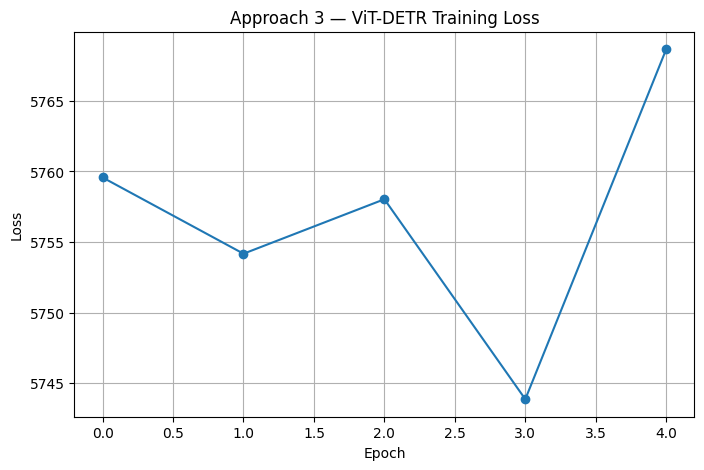

Detections: screenshot_90_png.rf.51b83dbe893f3e7d308bbe693371355c.jpg
  class=1 score=0.97 box=[319.99993896484375, 320.0, 959.9999389648438, 960.0]
  class=1 score=0.99 box=[319.9998474121094, 320.0, 959.9998779296875, 960.0]
  class=0 score=0.65 box=[319.9996337890625, 320.0, 959.9996337890625, 960.0]
  class=1 score=0.63 box=[319.99945068359375, 320.0, 959.9994506835938, 960.0]
  class=1 score=0.90 box=[319.999755859375, 320.0, 959.999755859375, 960.0]
  class=1 score=0.76 box=[319.9998474121094, 320.0, 959.9998779296875, 960.0]
  class=1 score=1.00 box=[319.9998474121094, 320.0, 959.9998779296875, 960.0]
Saved ViT-DETR model: /kaggle/working/vit_detr_head_body.pth


In [2]:
# ============================================================
# APPROACH 3 — ViT-DETR (FULL FINAL VERSION, FIXED)
# ============================================================

!pip install -q transformers datasets torchvision

import os
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import DetrForObjectDetection, DetrImageProcessor

# ============================================================
# 1. DEVICE + MODEL
# ============================================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

processor = DetrImageProcessor.from_pretrained("facebook/detr-resnet-50")
model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50").to(device)

print("Loaded DETR model.")

# ============================================================
# 2. DATASET PATHS
# ============================================================

dataset_path = "/kaggle/input/datasets/vananphan/objectdetection-andy"

train_img_dir = os.path.join(dataset_path, "train/images")
train_lbl_dir = os.path.join(dataset_path, "train/labels")

valid_img_dir = os.path.join(dataset_path, "valid/images")
valid_lbl_dir = os.path.join(dataset_path, "valid/labels")

test_img_dir  = os.path.join(dataset_path, "test/images")
test_lbl_dir  = os.path.join(dataset_path, "test/labels")

print("Train samples:", len(os.listdir(train_img_dir)))

# ============================================================
# 3. YOLO → PIXEL BOXES
# ============================================================

def read_yolo_labels(label_path, img_w, img_h):
    """
    Convert YOLO txt → pixel xyxy boxes.
    """
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])
            x_min = (xc - w/2) * img_w
            y_min = (yc - h/2) * img_h
            x_max = (xc + w/2) * img_w
            y_max = (yc + h/2) * img_h
            boxes.append([cls_id, x_min, y_min, x_max, y_max])
    return boxes

# ============================================================
# 4. DETR DATASET
# ============================================================

class DETRDataset(Dataset):
    def __init__(self, img_dir, lbl_dir):
        self.img_dir = img_dir
        self.lbl_dir = lbl_dir
        self.files = [f for f in os.listdir(img_dir)
                      if f.lower().endswith((".jpg", ".png", ".jpeg"))]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_name = self.files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        lbl_path = os.path.join(self.lbl_dir, img_name.rsplit(".",1)[0] + ".txt")

        image = Image.open(img_path).convert("RGB")
        img_w, img_h = image.size

        yolo_boxes = read_yolo_labels(lbl_path, img_w, img_h)

        if len(yolo_boxes) == 0:
            labels = torch.zeros((0,), dtype=torch.long)
            boxes  = torch.zeros((0,4), dtype=torch.float32)
        else:
            labels = torch.tensor([b[0] for b in yolo_boxes], dtype=torch.long)
            boxes  = torch.tensor([b[1:] for b in yolo_boxes], dtype=torch.float32)

        inputs = processor(images=image, return_tensors="pt")
        inputs = {k: v.squeeze(0) for k,v in inputs.items()}

        target = {
            "class_labels": labels,   # FIXED KEY
            "boxes": boxes            # FIXED FORMAT
        }

        return inputs, target

# ============================================================
# 5. DATALOADER
# ============================================================

train_dataset = DETRDataset(train_img_dir, train_lbl_dir)
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=lambda x: list(zip(*x))
)

print("Train dataset size:", len(train_dataset))

# ============================================================
# 6. TRAINING LOOP (FIXED)
# ============================================================

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
loss_history = []
num_epochs = 5  # tăng nếu muốn

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch_inputs, batch_targets in train_loader:
        pixel_values = torch.stack([bi["pixel_values"] for bi in batch_inputs]).to(device)

        targets = []
        for t in batch_targets:
            targets.append({
                "class_labels": t["class_labels"].to(device),
                "boxes": t["boxes"].to(device)
            })

        outputs = model(pixel_values=pixel_values, labels=targets)
        loss = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {avg_loss:.4f}")

# ============================================================
# 7. PLOT LOSS
# ============================================================

plt.figure(figsize=(8,5))
plt.plot(loss_history, marker='o')
plt.title("Approach 3 — ViT-DETR Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ============================================================
# 8. INFERENCE ON TEST IMAGE
# ============================================================

test_files = [f for f in os.listdir(test_img_dir)
              if f.lower().endswith((".jpg", ".png", ".jpeg"))]

if len(test_files) > 0:
    test_img_name = test_files[0]
    test_img_path = os.path.join(test_img_dir, test_img_name)

    image = Image.open(test_img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)

    results = processor.post_process_object_detection(
        outputs,
        threshold=0.5,
        target_sizes=[image.size[::-1]]
    )[0]

    print("Detections:", test_img_name)
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        print(f"  class={int(label)} score={float(score):.2f} box={box.tolist()}")

else:
    print("No test images found.")

# ============================================================
# 9. SAVE MODEL
# ============================================================

save_path = "/kaggle/working/vit_detr_head_body.pth"
torch.save(model.state_dict(), save_path)
print("Saved ViT-DETR model:", save_path)
